In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# STEPS in EDA:
## Get Data + Try To Understand Data and Relation Between Varaibles
## Feature Enegnering (30%)
## Feature Selection
## Model Creationg
## HyperParamter Tunning
## Model Deployments

### Get Data + Try To Understand Data and Relation Between Varaibles

In [3]:
df = pd.read_csv("/kaggle/input/datasets/abdellahkarani/renewable/Renewable.csv")
df.head(3)

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1


In [4]:
'''
    Feature Description:
        - Energy delta [WH]: Target Varaible
        - GHI (Irradiance): كمية الضو ديال الشمس لي كتوصل للأرض
            كلما طالع = طاقة أكثر
        - isSun: 0: night, 1: day
        - sunlightTime: time thst sun exit
        - dayLength:
        - SunlightTime/daylength: clean day or a little there is a little of cloud
            the values almost 1 --> clean day
        - clouds_all: percentage of clouds
            more clouds less energy
        - weather_type: type of weather
            0, 1, 2, 3, 4
        - humidity: ....
            low humidity = high energey
        - rain_1h: rain in last one hour
            affect energy
        - snow_1h: snow in last one hour
            affect a lot energy
        - temp
            hight temp = high energy
        - wind_speed
        - pressure
        - hour
        - month
'''
# df.nunique() # the values show us that there is more stable solar energy
# df["SunlightTime/daylength"].iloc[0: 1300]
# df["clouds_all"].iloc[400: 3490]
# df["temp"].iloc[400: 3490]
# df["weather_type"].iloc[400: 3490]
# df["Energy delta[Wh]"].iloc[400: 3490]
# df["humidity"].iloc[400: 3490]
# df["rain_1h"].iloc[0: 100]
# df["hour"].iloc[0:100]
# df["snow_1h"].unique()
# df["isSun"].iloc[0: 133]

# df.nunique()
df.describe()
# df.info()
# df.isnull().sum() # not null value in dataset

,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
count,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000
mean,573.008228,32.596538,9.790521,1015.292780,79.810566,3.937746,0.066035,0.007148,65.974387,0.519962,211.721094,748.644347,0.265187,3.198398,11.498902,6.298329
std,1044.824047,52.172018,7.995428,9.585773,15.604459,1.821694,0.278913,0.069710,36.628593,0.499603,273.902186,194.870208,0.329023,1.289939,6.921887,3.376066
min,0.000000,0.000000,-16.600000,977.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,450.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,0.000000,3.600000,1010.000000,70.000000,2.600000,0.000000,0.000000,34.000000,0.000000,0.000000,570.000000,0.000000,2.000000,5.000000,3.000000
50%,0.000000,1.600000,9.300000,1016.000000,84.000000,3.700000,0.000000,0.000000,82.000000,1.000000,30.000000,765.000000,0.050000,4.000000,11.000000,6.000000
75%,577.000000,46.800000,15.700000,1021.000000,92.000000,5.000000,0.000000,0.000000,100.000000,1.000000,390.000000,930.000000,0.530000,4.000000,17.000000,9.000000
max,5020.000000,229.200000,35.800000,1047.000000,100.000000,14.300000,8.090000,2.820000,100.000000,1.000000,1020.000000,1020.000000,1.000000,5.000000,23.000000,12.000000


In [5]:
df.head(2)

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1


In [6]:
# Correlation Between Varaible
df = df.drop(["Time"], axis=1)

In [7]:
df.corr()

,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
Energy delta[Wh],1.000000,0.914619,0.378554,0.115219,-0.544407,0.029385,-0.059881,-0.050914,-0.190241,0.526952,0.437296,0.280695,0.402523,-0.170046,-0.080877,-0.049307
GHI,0.914619,1.000000,0.492732,0.096392,-0.602186,0.017227,-0.048570,-0.051811,-0.188765,0.600326,0.540151,0.401115,0.471907,-0.163616,-0.083727,-0.039461
temp,0.378554,0.492732,1.000000,-0.066909,-0.517358,-0.080258,0.073826,-0.123244,-0.117245,0.345600,0.504449,0.706510,0.382672,-0.088711,0.104091,0.250656
pressure,0.115219,0.096392,-0.066909,1.000000,-0.120481,-0.313964,-0.201842,-0.135485,-0.263852,0.014872,0.006731,0.053127,0.001791,-0.319925,-0.002519,-0.061383
humidity,-0.544407,-0.602186,-0.517358,-0.120481,1.000000,-0.112949,0.126620,0.095623,0.285336,-0.389144,-0.598166,-0.416460,-0.527887,0.286863,-0.194924,0.117468
wind_speed,0.029385,0.017227,-0.080258,-0.313964,-0.112949,1.000000,0.123506,0.072749,0.146116,0.082700,0.054580,-0.210064,0.092661,0.193744,-0.003593,-0.045010
rain_1h,-0.059881,-0.048570,0.073826,-0.201842,0.126620,0.123506,1.000000,-0.024276,0.173332,0.045241,0.059318,0.048428,0.050164,0.330671,0.011388,0.022221
snow_1h,-0.050914,-0.051811,-0.123244,-0.135485,0.095623,0.072749,-0.024276,1.000000,0.088428,-0.023257,-0.038293,-0.109050,-0.021457,0.143205,-0.004609,-0.080668
clouds_all,-0.190241,-0.188765,-0.117245,-0.263852,0.285336,0.146116,0.173332,0.088428,1.000000,-0.002928,-0.030415,-0.234957,0.004761,0.910932,-0.019384,0.066102
isSun,0.526952,0.600326,0.345600,0.014872,-0.389144,0.082700,0.045241,-0.023257,-0.002928,1.000000,0.742715,0.270923,0.774424,0.024333,-0.150529,-0.024573


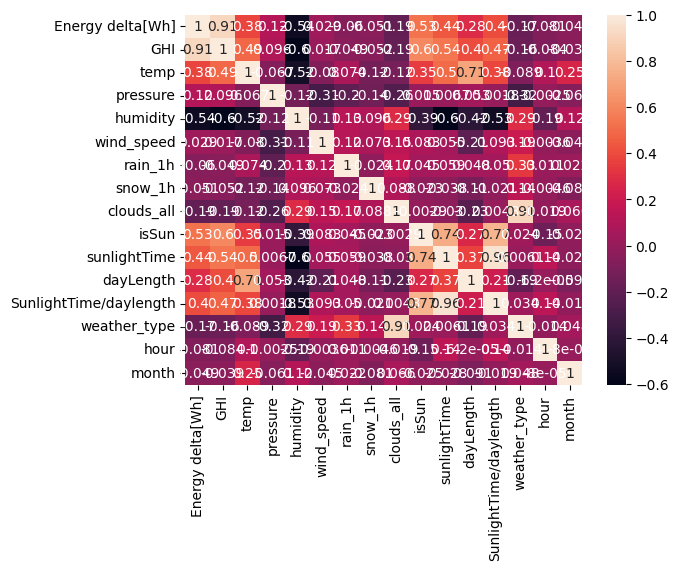

<Figure size 2000x1200 with 0 Axes>

In [8]:
# Visual the Correlation
sns.heatmap(df.corr(), annot=True)
# plt.rcParams["figure.figsize"] = (20, 7)
plt.figure(0, figsize=(20, 12))
plt.show()

In [9]:
# Group The Data by IsSun and Month and weather_type
# df["IsSun"].unique()
# df["month"].unique()
df0 = df.groupby("weather_type").mean()
df2 = df.groupby("month").mean()
df1 = df.groupby("isSun").mean()
df1

,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
isSun,,,,,,,,,,,,,,,
0,0.000000,0.000000,6.914696,1015.144410,86.130394,3.780954,0.052902,0.008835,66.085994,0.000000,693.698073,0.000000,3.165732,12.583305,6.384671
1,1102.019889,62.690257,12.445535,1015.429757,73.975986,4.082500,0.078159,0.005590,65.871350,407.185875,799.371750,0.510012,3.228557,10.497762,6.218617


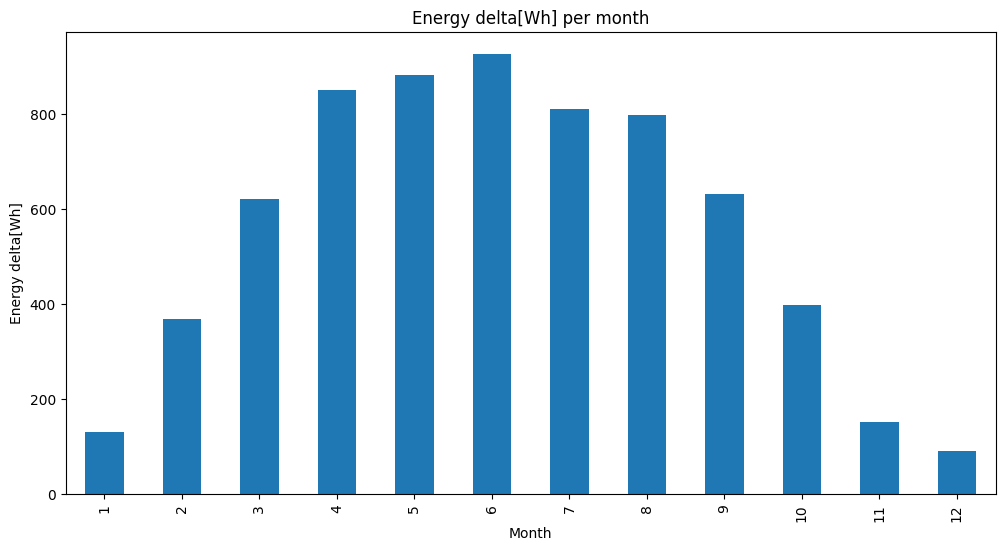

In [10]:
# Visual Energy delta[Wh] values per month
df2["Energy delta[Wh]"].plot(kind="bar", figsize=(12,6))

plt.xlabel("Month")
plt.ylabel("Energy delta[Wh]")
plt.title("Energy delta[Wh] per month")
plt.show()

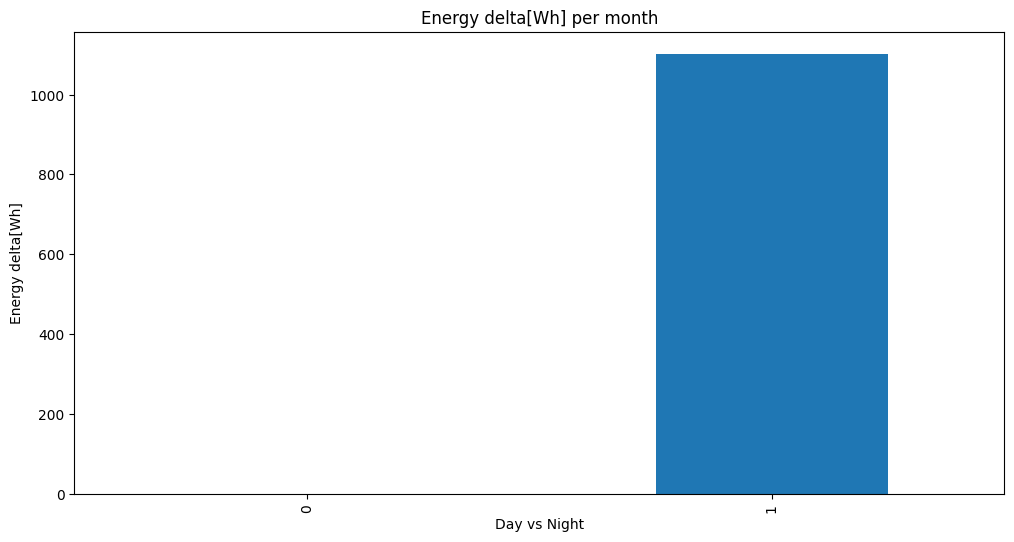

In [11]:
df[np.array(df["isSun"] == 0)]
# Visual Energy delta[Wh] values in Day vs Night
df1["Energy delta[Wh]"].plot(kind="bar", figsize=(12,6))

plt.xlabel("Day vs Night")
plt.ylabel("Energy delta[Wh]")
plt.title("Energy delta[Wh] per month")
plt.show()

## Feature Engineering

In [12]:
# Feature Engineering
'''
    src: https://www.youtube.com/watch?v=xhB-dmKmzRk
'''

'\n    src: https://www.youtube.com/watch?v=xhB-dmKmzRk\n'

In [13]:
# Feature Selection:
'''
    - Feature With High correlation with target varaible are selected.
        --> sometime we find some features usefull and no linear. --> is not good way to based on just correlation
    - 
    src: https://www.youtube.com/watch?v=tqpIyvCl4fI
'''

'\n    - Feature With High correlation with target varaible are selected.\n        --> sometime we find some features usefull and no linear. --> is not good way to based on just correlation\n    - \n    src: https://www.youtube.com/watch?v=tqpIyvCl4fI\n'

In [14]:
# Find Outliers + Deal With It


In [15]:
# Feature distributions


In [16]:
# find imbalance feature


In [17]:
# Is that Data Lineare or NO